# Tester Values for (P, Cd*A, phi, K_longitudinal)

Estimated top speed (where +ax→0): V ≈ 41.25 m/s


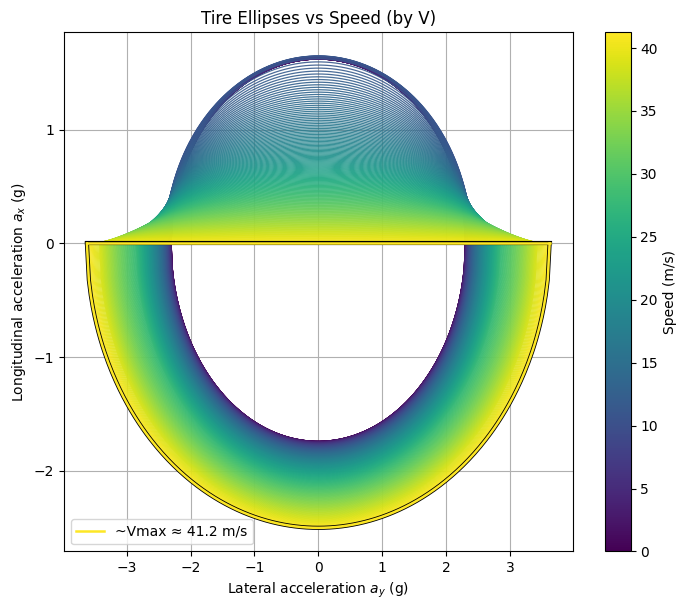

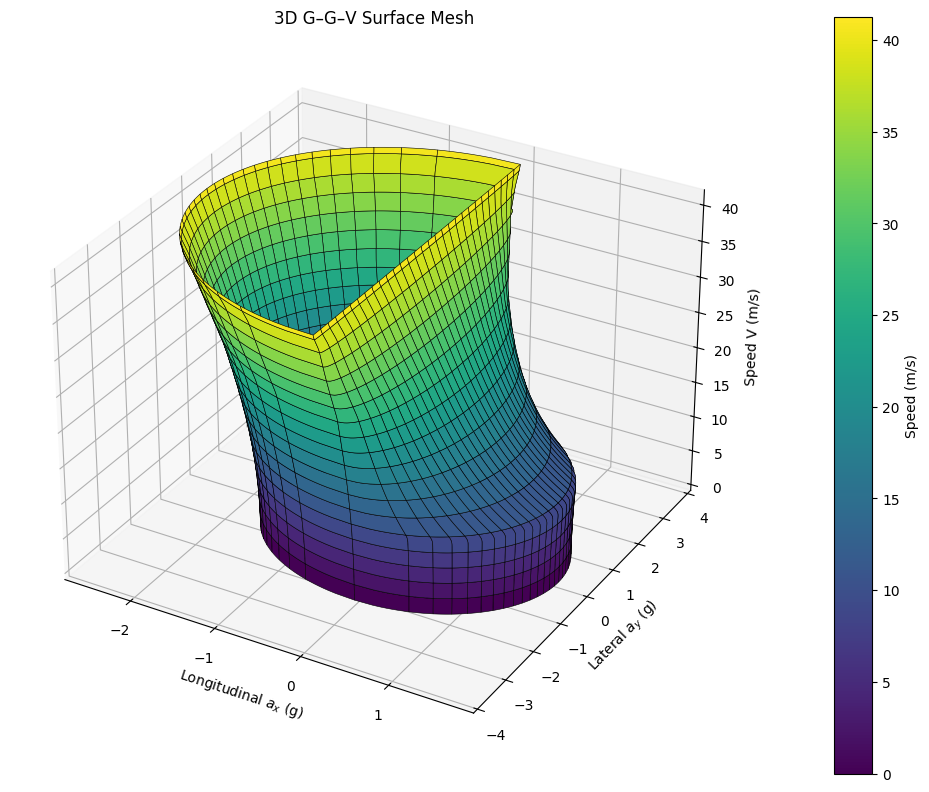

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import minimize_scalar

# Vehicle & aero inputs

M        = 307.0     # kg
G        = 9.81      # m/s^2
WHEELBASE= 1.550     # m
TRACK    = 1.208     # m
H_CG     = 0.280     # m
FRONT_STATIC_FRAC = 0.53  # front axle fraction


# Downforce constants to calculate:
RHO = 1.225   # kg/m^3 
CL  = -1.937755   
A   = 1.0     # m^2
AERO_FRONT_BALANCE = 0.50  # the fraction of aero load on the front axle

# Power & drag cap
P_WN   = 60000.0       # W, wheel power available
ETA_DR = 0.92       # drivetrain efficiency??
CDA    = 1.30       # m^2, aerodynamic drag area

# LLTD parameters
PHI_FRONT = 0.50  # fraction of lateral load transfer on front axle (rest is rear)
K_LONGITUDINAL = 1.0  # longitudinal load transfer scale factor (1.0 = full transfer, 0.0 = no transfer)


# Driveline assumption
DRIVEN_AXLE = "rear"

PER_WHEEL_SPEED_ITERATIONS = 20  # how many iterations to do to converge on the per-wheel loads for each speed (for the transfer effects)

# Loads vs speed
W = M*G

def aero_downforce(V):  # positive magnitude
    return 0.5 * RHO * A * abs(CL) * V*V


## Need to get Cd*A here !!!
def aero_drag_force(V):
    if CDA is None:
        return 0.0
    return 0.5 * RHO * CDA * V*V

# PACEJKA CALCULATIONS----------------------------------------------------------------------------------------------

# Lateral (Fy) Coefficients
def B_lat(Fz): return -0.3488 - 0.0003*Fz - 1.3e-7*(Fz**2)
def C_lat(Fz): return 0.55092222 - 0.00244369*Fz - 1.0e-6*(Fz**2)
def D_lat(Fz): return 338.399 - 1.97694*Fz
def E_lat(Fz): 
    # Cap Fz at a reasonable maximum (e.g., 5000N or 8000N) 
    # This term for some reason will blow up if the force is too much...keep it constant after a certian amoutn -> Optimiz
    Fz_capped = np.clip(Fz, 0, 8000) 
    return 0.35539 + 31.2449 * np.exp(0.0164059 * Fz_capped)
    
def F_lat(Fz): return -0.0233809 - 1.77392e-4*Fz - 1.21226e-7*(Fz**2)

# See Appendix of SAE-2011-01-0094 for how this is calculated
#https://file.notion.so/f/f/e824069c-9836-4508-b929-10beff09e46f/381a0b90-55f4-40c7-80f4-26fe463e8fe6/SAE-2011-01-0094-Brach-Engineering_(3)_(3).pdf?table=block&id=274538db-02df-80b3-8cb7-f57f59dd3f68&spaceId=e824069c-9836-4508-b929-10beff09e46f&expirationTimestamp=1773705600000&signature=gAMl9a9outgHLSD-5H0Ji_REmscDc0MDsmgOUXc1Uww&downloadName=SAE-2011-01-0094-Brach-Engineering+%283%29+%283%29.pdf

def calculate_fy_pure(slip_angle, load):

    Fz = -np.abs(load) # Flip magnitude to positive for the equations since they are based on negative loads

    stiffness = B_lat(Fz)
    shape = C_lat(Fz)
    peak = D_lat(Fz)
    curvature = E_lat(Fz)
    shift = F_lat(Fz)
    
    return peak * np.sin(shape * np.arctan(stiffness * slip_angle - curvature * (stiffness * slip_angle - np.arctan(stiffness * slip_angle)))) + shift

# Longitudinal (Fx) Coefficients
# def B_long(Fz): return -17.3662 - 9.50547*np.exp(0.00226287*Fz)
# def C_long(Fz): return -0.00127868 + 1.35334e-5*Fz + 4.86905e-9*(Fz**2)
# def D_long(Fz): return 43690.6 - 173.535*Fz - 0.0708504*(Fz**2)
# def E_long(Fz): return -1.42217 + 0.0015213*Fz
# def F_long(Fz): return 1.76214e-4 - 2.74311e-7*Fz

# Really dummy constants cuz apparently the above constants are broken
def B_long(Fz): return 12.0 + 0.002 * Fz
def C_long(Fz): return 1.6 + 0.00005 * Fz
def D_long(Fz): return -2.2 * Fz - 0.0004 * (Fz**2)
def E_long(Fz): return 0.1 + 0.0001 * Fz
def F_long(Fz): return 0.0

def calculate_fx_pure(slip_ratio, load):

    Fz = -np.abs(load) # Flip magnitude to positive for the equations since they are based on negative loads

    stiffness = B_long(Fz)
    shape = C_long(Fz)
    peak = D_long(Fz)
    curvature = E_long(Fz)
    shift = F_long(Fz)
    
    return peak * np.sin(shape * np.arctan(stiffness * slip_ratio - curvature * (stiffness * slip_ratio - np.arctan(stiffness * slip_ratio)))) + shift



# Modified Nicolas-Comstock (MNC) Combined Forces
#https://file.notion.so/f/f/e824069c-9836-4508-b929-10beff09e46f/381a0b90-55f4-40c7-80f4-26fe463e8fe6/SAE-2011-01-0094-Brach-Engineering_(3)_(3).pdf?table=block&id=274538db-02df-80b3-8cb7-f57f59dd3f68&spaceId=e824069c-9836-4508-b929-10beff09e46f&expirationTimestamp=1773705600000&signature=gAMl9a9outgHLSD-5H0Ji_REmscDc0MDsmgOUXc1Uww&downloadName=SAE-2011-01-0094-Brach-Engineering+%283%29+%283%29.pdf
# See above paper on page 3
# Implements Equations 3 and 4 from SAE-2011-01-0094.
def calculate_mnc_combined_forces(slip_angle_rad, slip_ratio, load):
    eps = 1e-8  # denominator protection
    Fz = -np.abs(load) 
    
    # Tire Model Inputs: Convert to degrees for the Pacejka/BNP functions
    # Figure A-2 and Eq A-2 use alpha in degrees [cite: 429, 442]
    alpha_deg = np.rad2deg(slip_angle_rad)
    
    # Calculate Pure Forces
    # Fx(s) and Fy(alpha) [cite: 384, 385, 390]
    Fx_s = calculate_fx_pure(slip_ratio, Fz)
    Fy_alpha = calculate_fy_pure(alpha_deg, Fz)
    
    # Calculate Stiffness (Slopes at zero)
    # C_alpha must be in Force/Radian to be consistent with sin/tan in MNC [cite: 116, 118]
    # If your B,C,D constants are 'per degree', multiply by (180/pi)
    C_alpha_deg = B_lat(Fz) * C_lat(Fz) * D_lat(Fz)
    C_alpha_rad = C_alpha_deg * (180.0 / np.pi)
    
    C_s = B_long(Fz) * C_long(Fz) * D_long(Fz) # s is unitless, so C_s is Force/UnitSlip
    
    # MNC Denominator: sqrt(s^2 * Fy_a^2 + Fx_s^2 * tan^2(alpha)) [cite: 116, 118]
    tan_a = np.tan(slip_angle_rad)
    cos_a = np.cos(slip_angle_rad)
    sin_a = np.sin(slip_angle_rad)
    
    denom_sq = (slip_ratio**2 * Fy_alpha**2) + (Fx_s**2 * tan_a**2)
    denom = np.sqrt(np.maximum(denom_sq, eps**2))
    
    # 5. Longitudinal Combined Force: Fx(alpha, s) [Eq. 3]
    # Note: s in the denominator of the second quotient cancels the s in the first [cite: 116]
    term1_x = (Fx_s * Fy_alpha * slip_ratio) / denom
    num2_x = np.sqrt((slip_ratio**2 * C_alpha_rad**2) + ((1 - np.abs(slip_ratio))**2 * cos_a**2 * Fx_s**2))
    Fx_alpha_s = term1_x * (num2_x / (np.maximum(np.abs(slip_ratio * C_alpha_rad), eps)))
    
    # 6. Lateral Combined Force: Fy(alpha, s) [Eq. 4]
    term1_y = (Fx_s * Fy_alpha * tan_a) / denom
    num2_y = np.sqrt(((1 - np.abs(slip_ratio))**2 * cos_a**2 * Fy_alpha**2) + (sin_a**2 * C_s**2))
    Fy_alpha_s = term1_y * (num2_y / (np.maximum(np.abs(C_s * sin_a), eps)))

    # 7. Final Sanity Checks for zero-slip cases
    Fx_final = np.where(np.abs(slip_angle_rad) < eps, Fx_s, Fx_alpha_s)
    Fx_final = np.where(np.abs(slip_ratio) < eps, 0.0, Fx_final)

    Fy_final = np.where(np.abs(slip_ratio) < eps, Fy_alpha, Fy_alpha_s)
    Fy_final = np.where(np.abs(slip_angle_rad) < eps, 0.0, Fy_final)

    return Fx_final, Fy_final

def peak_lateral(load, max_slip_angle_deg=25.0, max_slip_ratio=0.15):
    # Create a 2D mesh to evaluate combinations of slip angle and slip ratio
    angles = np.deg2rad(np.linspace(-max_slip_angle_deg, max_slip_angle_deg, 150))
    ratios = np.linspace(-max_slip_ratio, max_slip_ratio, 150)
    
    angle_grid, ratio_grid = np.meshgrid(angles, ratios)
    _, fy_combined = calculate_mnc_combined_forces(angle_grid, ratio_grid, load)
    
    # The peak is the absolute maximum over the combined envelope
    return float(np.max(fy_combined))


def peak_longitudinal(load, max_slip_angle_deg=25.0, max_slip_ratio=0.15):
    angles = np.deg2rad(np.linspace(-max_slip_angle_deg, max_slip_angle_deg, 150))
    ratios = np.linspace(-max_slip_ratio, max_slip_ratio, 150)
    
    angle_grid, ratio_grid = np.meshgrid(angles, ratios)
    fx_combined, _ = calculate_mnc_combined_forces(angle_grid, ratio_grid, load)
    
    return float(np.max(fx_combined))



def per_wheel_loads(V, ax, ay, m=M, g=G, wheelbase=WHEELBASE, track=TRACK, h_cg=H_CG, front_static_frac=FRONT_STATIC_FRAC, 
                    rho=RHO, Cl=CL, A=A, 
                    aero_front_balance=AERO_FRONT_BALANCE,
                    k_longitudinal = K_LONGITUDINAL,     
                    phi_front=PHI_FRONT  
                   ):
    ## k is the longitudinal transfer scale factor (pitch)
    # phi is the lateral tranfer (roll)
    
    """
    So for every wheels load we add these:
      - the regular static weight split i found from slack (0.53 front)
      - aero downforce split i just assumed is just divided by 2
      - longitudinal load transfer (pitch) from ax
      - lateral load transfer (roll) from ay
    this will return: Fz_fl, Fz_fr, Fz_rl, Fz_rr for the normal loads
    """
    
    # Basic axle loads just from the static + aero
    W  = m * g
    D  = 0.5 * rho * A * abs(Cl) * V * V  # total downforce magnitude (this is positive)
    Wf_base = W * front_static_frac       + D * aero_front_balance
    Wr_base = W * (1 - front_static_frac) + D * (1 - aero_front_balance)

    # Longitudinal transfer (pitch): +ax -> this is when the rear gains, and the front loses
    dF_long = k_longitudinal * (m * ax * h_cg / wheelbase)
    Wf = Wf_base - dF_long
    Wr = Wr_base + dF_long

    # start with equal left/right normal force on each axle
    Fz_fl = Fz_fr = Wf * 0.5
    Fz_rl = Fz_rr = Wr * 0.5

    # Lateral transfer (roll): ay>0 -> outside side of car gains
    dF_lat_total = m * abs(ay) * h_cg / track
    dF_lat_f = phi_front * dF_lat_total
    dF_lat_r = (1 - phi_front) * dF_lat_total
    sign = 1.0 if ay > 0 else (-1.0 if ay < 0 else 0.0)

    Fz_fl -= sign * dF_lat_f * 0.5; Fz_fr += sign * dF_lat_f * 0.5
    Fz_rl -= sign * dF_lat_r * 0.5; Fz_rr += sign * dF_lat_r * 0.5

    # make sure we dont have to worry about div by 0, NaN/inf
    eps = 1e-3
    return max(Fz_fl, eps), max(Fz_fr, eps), max(Fz_rl, eps), max(Fz_rr, eps)

# Per-speed tire limits with power & drag cap
def per_speed_limits(V, k_longitudinal=2, phi_front=PHI_FRONT):
    
    ay = 0.0
    # Pure lateral limit (ax = 0) with roll transfer 
    for _ in range(PER_WHEEL_SPEED_ITERATIONS):
        
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=0.0, ay=ay, k_longitudinal=k_longitudinal, phi_front=phi_front)
        
        #Get the maximum lateral grip force available at EACH axle
        Fy_front_max = peak_lateral(Fz_fl) + peak_lateral(Fz_fr)
        Fy_rear_max  = peak_lateral(Fz_rl) + peak_lateral(Fz_rr)
        
        # Calculate the max vehicle acceleration if constrained by the FRONT axle (Understeer Limit)
        # The front axle must provide a percentage of total lateral force equal to its static weight distribution
        ay_limit_front = (Fy_front_max / phi_front) / M
        
        #  Calculate the max vehicle acceleration if constrained by the REAR axle (Oversteer Limit)
        ay_limit_rear = (Fy_rear_max / (1.0 - phi_front)) / M
        
        #  The true target is the absolute minimum of these two limits
        ay_target = min(ay_limit_front, ay_limit_rear)

        
        if abs(ay_target - ay) < 1e-3: 
            ay = ay_target
            break
            
        ay = ay_target
    ay_max = ay

    # Pure acceleration limit (ay = 0) with pitch transfer
    ax_accel = 0.0
    for _ in range(PER_WHEEL_SPEED_ITERATIONS):
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=ax_accel, ay=0.0, k_longitudinal=k_longitudinal, phi_front=phi_front)
        Fx_sum = (peak_longitudinal(Fz_fl) + peak_longitudinal(Fz_fr) +
                    peak_longitudinal(Fz_rl) + peak_longitudinal(Fz_rr))
        ax_tire = Fx_sum / M # tire limited accel (traction limited given the normal modes)

        # Power + drag cap 
        Veff  = max(V, 1e-3)
        if (P_WN is None) or (ETA_DR is None) or (CDA is None):
            ax_pow = np.inf
        else:
            P_av  = ETA_DR * P_WN
            Fd    = aero_drag_force(V)
            ax_pow = max(0.0, (P_av - Fd*Veff) / (M * Veff)) #this is the power limited accel for a V if we could have infinite grip

        #the min is needed because we these are 2 constraints, so the tire can't push harder than the power allows, or we cant have power pushing more than the tire allows!!
        ax_target = min(ax_tire, ax_pow)
        
        if abs(ax_target - ax_accel) < 1e-3: 
            ax_accel = ax_target
            break

        ax_accel = ax_target
    ax_pos_max = ax_accel

    # Pure braking limit (ay = 0) with pitch transfer (dont need power cap because here it is just tire limited, we arent supplying any energy here)
    ax_brake = 0.0
    for _ in range(PER_WHEEL_SPEED_ITERATIONS):
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=ax_brake, ay=0.0, k_longitudinal =K_LONGITUDINAL, phi_front=PHI_FRONT)
        Fx_sum_all = (peak_longitudinal(Fz_fl) + peak_longitudinal(Fz_fr) +
                      peak_longitudinal(Fz_rl) + peak_longitudinal(Fz_rr))
        ax_new = -(Fx_sum_all / M)  # negative = braking
        if abs(ax_new - ax_brake) < 1e-3:
            break
        ax_brake = ax_new
    ax_neg_max = -ax_brake  # return positive magnitude

    return ax_pos_max, ax_neg_max, ay_max


#When ax = 0 or really near 0, this is our max/top speed! (pwheel ower equals drag power)
#when we call this, V_list is created with the min V and max V with small steps
def compute_vmax(V_list, ax_pos_list, thresh=1e-3):
    """
     If +ax never drops to <= thresh within V_list, returns (None, None, None).
     """
    ax = np.array(ax_pos_list) #make array of ax for ax from each V
    
    # find first index where +ax <= thresh
    below = np.where(ax <= thresh)[0]
    
    if len(below) == 0:
        return None, None, None  # no crossing in the scanned range
    i2 = int(below[0]) #first index where ax <= threshold
    if i2 == 0:
        return V_list[0], None, i2
    i1 = i2 - 1
    # linear interpolation between (V1, a1) and (V2, a2) to estimate an ax=0 crossing
    V1, V2 = V_list[i1], V_list[i2]
    a1, a2 = ax[i1], ax[i2]
    if a2 == a1:
        return V2, i1, i2
    V_top = V1 + (0.0 - a1) * (V2 - V1) / (a2 - a1)
    return V_top, i1, i2


# Build ellipses + GGV (0 m/s to 60 m/s)
def build_ellipses_and_ggv(V_min=0.0, V_max=60.0, nV=241, n_ellipse_pts=241):
    """
    Returns:
      ellipses_2d: list of (V, ax_neg[], ay[], ax_pos[]) in m/s^2
      ggv_points : array Nx3 of [V, ax, ay] in SI
      ax_pos_arr : +ax limit per V (for Vmax calculation)
    """
    V_list = np.linspace(V_min, V_max, nV)
    ellipses_2d = []
    ggv_rows = []
    ax_pos_arr = []

    for V in V_list:
        ax_pos_max, ax_neg_max, ay_max = per_speed_limits(V) 
        if not np.isfinite([ax_pos_max, ax_neg_max, ay_max]).all() or ay_max <= 0:
            ax_pos_arr.append(np.nan)
            continue
        # store +ax for Vmax finding
        ax_pos_arr.append(ax_pos_max)

        # ellipse points at this speed
        ax_neg, ay, ax_pos = ellipse_points(ax_pos_max, ax_neg_max, ay_max, n=n_ellipse_pts)
        msk_p = np.isfinite(ax_pos) & np.isfinite(ay)
        msk_n = np.isfinite(ax_neg) & np.isfinite(ay)
        ellipses_2d.append((V, ax_neg[msk_n], ay[msk_n], ax_pos[msk_p]))

        # GGV cloud (both sides of ellipse)
        ggv_rows += [(V, ax, yy) for ax, yy in zip(ax_pos[msk_p], ay[msk_p])]
        ggv_rows += [(V, ax, yy) for ax, yy in zip(ax_neg[msk_n], ay[msk_n])]

    ggv_points = np.array(ggv_rows) if len(ggv_rows) else np.zeros((0,3))
    return V_list, ellipses_2d, ggv_points, np.array(ax_pos_arr, dtype=float)



def plot_ellipses_ombre(ellipses_2d, V_highlight=None, cmap_name='viridis', g=G):
    if not ellipses_2d:
        print("No valid ellipses to plot.")
        return
        
    speeds = np.array([e[0] for e in ellipses_2d])
    cmap   = plt.get_cmap(cmap_name)
    norm   = mpl.colors.Normalize(vmin=speeds.min(), vmax=speeds.max())

    fig, ax = plt.subplots(figsize=(7.2, 6.2))

    # 1. Pre-calculate the index of the ellipse nearest to V_highlight
    target_idx = None
    if V_highlight is not None:
        target_idx = int(np.argmin(np.abs(speeds - V_highlight)))

    # 2. Draw ellipses and stop if we hit the highlighted one
    for i, (V, ax_neg, ay, ax_pos) in enumerate(ellipses_2d):
        c = cmap(norm(V))
        
        # Check if we have reached the target ellipse
        if target_idx is not None and i == target_idx:
            # Plot the highlighted ellipse
            ax.plot(ay/g, ax_pos/g, color='k', linewidth=3.0, zorder=5)
            ax.plot(ay/g, ax_neg/g, color='k', linewidth=3.0, zorder=5)
            ax.plot(ay/g, ax_pos/g, color=c, linewidth=1.8, zorder=6, label=f"~Vmax ≈ {V_highlight:.1f} m/s")
            ax.plot(ay/g, ax_neg/g, color=c, linewidth=1.8, zorder=6)
            
            # Stop the loop here so no faster speeds are plotted
            break 
        else:
            # Plot standard ellipse
            ax.plot(ay/g, ax_pos/g, color=c, linewidth=0.9, alpha=0.9)
            ax.plot(ay/g, ax_neg/g, color=c, linewidth=0.9, alpha=0.9)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Speed (m/s)')

    ax.set_xlabel('Lateral acceleration $a_y$ (g)')
    ax.set_ylabel('Longitudinal acceleration $a_x$ (g)')
    ax.set_title('Tire Ellipses vs Speed (by V)')
    
    if V_highlight is not None:
        ax.legend(loc='lower left', frameon=True)
        
    ax.grid(True)
    fig.tight_layout()
    plt.show()


# Plot 3D GGV (speed on Z-axis), highlight Vmax ellipse as a 3D ring
def plot_ggv_3d(ggv_points, ellipses_2d, V_highlight=None, cmap_name='viridis', g=G):
    if ggv_points.size == 0:
        print("No GGV points to plot."); return
    V  = ggv_points[:,0]
    axg= ggv_points[:,1]/g
    ayg= ggv_points[:,2]/g

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=V.min(), vmax=V.max())

    fig = plt.figure(figsize=(8,6.4))
    ax3d = fig.add_subplot(111, projection='3d')

    # =scatter with Speed on Z axis (colored by V)
    sc = ax3d.scatter(axg, ayg, V, c=V, cmap=cmap, norm=norm, s=6, depthshade=False)

    # overlay Vmax ellipse as a 3D line at Z = V_highlight
    if (V_highlight is not None) and len(ellipses_2d):
        speeds = np.array([e[0] for e in ellipses_2d])
        idx = int(np.argmin(np.abs(speeds - V_highlight)))
        Vh, ax_neg, ay, ax_pos = ellipses_2d[idx]
        ch = cmap(norm(Vh))
        # Outline (black) at constant Z = Vh
        ax3d.plot(ax_pos/g, ay/g, np.full_like(ax_pos, Vh), color='k', linewidth=3.0, zorder=5)
        ax3d.plot(ax_neg/g, ay/g, np.full_like(ax_neg, Vh), color='k', linewidth=3.0, zorder=5)
        # Colored on top
        ax3d.plot(ax_pos/g, ay/g, np.full_like(ax_pos, Vh), color=ch, linewidth=1.8, zorder=6)
        ax3d.plot(ax_neg/g, ay/g, np.full_like(ax_neg, Vh), color=ch, linewidth=1.8, zorder=6)

    # labeling and formatting
    ax3d.set_xlabel('Longitudinal $a_x$ (g)')
    ax3d.set_ylabel('Lateral $a_y$ (g)')
    ax3d.set_zlabel('Speed V (m/s)') 
    ax3d.set_title('3D G–G–V (by V; Z = speed)')

    cbar = plt.colorbar(sc, ax=ax3d, pad=0.10)
    cbar.set_label('Speed (m/s)')

    fig.tight_layout()
    plt.show()

# 3d Plot
def plot_ggv_3d_surface(ellipses_2d, V_highlight=None, cmap_name='viridis', g=G):

    # 0 check we have data to plot
    if not ellipses_2d:
        print("No GGV points to plot."); return
        
    # 1. Unpack the lists into 2D matrices (The Grid)
    # Shape of each will be (nV, n_ellipse_pts) -> (241, 241)
    V_grid = (np.array([[e[0]] * len(e[2]) for e in ellipses_2d]))
    ax_neg_grid = np.array([e[1] for e in ellipses_2d]) / g      
    ay_grid = np.array([e[2] for e in ellipses_2d]) / g          
    ax_pos_grid = np.array([e[3] for e in ellipses_2d]) / g  

    smooth_sigma = 2 
    ax_pos_grid = gaussian_filter1d(ax_pos_grid, sigma=smooth_sigma, axis=0)
    ax_neg_grid = gaussian_filter1d(ax_neg_grid, sigma=smooth_sigma, axis=0)
    ay_grid = gaussian_filter1d(ay_grid, sigma=smooth_sigma, axis=0)

    # Setup figure
    fig = plt.figure(figsize=(10, 8))
    ax3d = fig.add_subplot(111, projection='3d')

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=V_grid.min(), vmax=V_grid.max())

    # 2. Plot the surfaces
    # Bottom half (-ax, Braking)
    surf2 = ax3d.plot_surface(ax_neg_grid, ay_grid, V_grid, 
                             facecolors=cmap(norm(V_grid)), 
                             rstride=12, cstride=8, antialiased=True, shade=False, alpha=1,
                             linewidth=0.4, edgecolor='k')

    # Top half (+ax, Acceleration)
    surf1 = ax3d.plot_surface(ax_pos_grid, ay_grid, V_grid, 
                             facecolors=cmap(norm(V_grid)), 
                             rstride=12, cstride=8, antialiased=True, shade=False, alpha=1,
                             linewidth=0.4, edgecolor='k')

    # Labels and formatting
    ax3d.set_xlabel('Longitudinal $a_x$ (g)')
    ax3d.set_ylabel('Lateral $a_y$ (g)')
    ax3d.set_zlabel('Speed V (m/s)') 
    ax3d.set_title('3D G–G–V Surface Mesh')

    # Colorbar needs a scalar mappable for surfaces
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax3d, pad=0.10)
    cbar.set_label('Speed (m/s)')

    fig.tight_layout()
    plt.show()


def ellipse_points(ax_pos_max, ax_neg_max, ay_max, n=241):
    ay = np.linspace(-max(ay_max, 1e-12), max(ay_max, 1e-12), n)
    ax_pos =  ax_pos_max * np.sqrt(np.maximum(0.0, 1.0 - (ay/ay_max)**2))
    ax_neg = -ax_neg_max * np.sqrt(np.maximum(0.0, 1.0 - (ay/ay_max)**2))
    return ax_neg, ay, ax_pos


# RUN everything:
CMAP_NAME = 'viridis'  

V_list, ellipses_2d, ggv_points, ax_pos_arr = build_ellipses_and_ggv(V_min=0.0, V_max=45.0, nV=241, n_ellipse_pts=241)

# compute Vmax from +ax(V) curve
V_max_est, i1, i2 = compute_vmax(V_list, ax_pos_arr, thresh=1e-3)

# choose which ellipse to bold/outline --> this would be the top speed
V_highlight = V_max_est if V_max_est is not None else (V_list[-1] if len(V_list) else None)

# helpful print about top speed
if V_max_est is None:
    print("Top speed not reached within 0 m/s to 60 m/s (no +ax close to 0 crossing). Highlighting the highest speed in range instead.")
else:
    print(f"Estimated top speed (where +ax→0): V ≈ {V_max_est:.2f} m/s")

#only include ellipses up to Vmax_est
ellipses_2d = [e for e in ellipses_2d if e[0] <= (V_max_est if V_max_est else 60)]

# Draw plots!!
plot_ellipses_ombre(ellipses_2d, V_highlight=V_highlight, cmap_name=CMAP_NAME, g=G)
plot_ggv_3d_surface(ellipses_2d, V_highlight=V_highlight, cmap_name=CMAP_NAME, g=G)
#plot_ggv_3d(ggv_points, ellipses_2d, V_highlight=None, cmap_name='viridis', g=9.81)


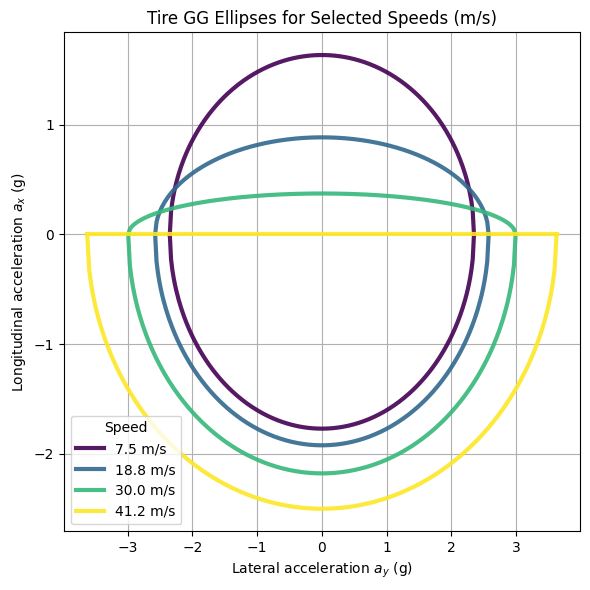

In [3]:
def plot_ellipses(ellipses_2d, V_highlight=None, cmap_name='viridis', g=G):
    if not ellipses_2d:
        print("No valid ellipses to plot.")
        return
        
    speeds = np.array([e[0] for e in ellipses_2d])
    cmap   = plt.get_cmap(cmap_name)
    norm   = mpl.colors.Normalize(vmin=speeds.min(), vmax=speeds.max())

    fig, ax = plt.subplots(figsize=(6, 6))

    # Draw ellipses 
    for i, (V, ax_neg, ay, ax_pos) in enumerate(ellipses_2d):
        c = cmap(norm(V))
        ax.plot(ay/g, ax_pos/g, color=c, linewidth=3, alpha=0.9, label=f"{V:.1f} m/s")
        ax.plot(ay/g, ax_neg/g, color=c, linewidth=3, alpha=0.9)

    ax.legend(loc='lower left', title='Speed')

    ax.set_xlabel('Lateral acceleration $a_y$ (g)')
    ax.set_ylabel('Longitudinal acceleration $a_x$ (g)')
    ax.set_title('Tire GG Ellipses for Selected Speeds (m/s)')
        
    ax.grid(True)
    fig.tight_layout()
    plt.show()

selected_ellipses = [ellipses_2d[i] for i in range(40, len(ellipses_2d), 60)] # example cornering speeds to analyze
plot_ellipses(selected_ellipses, V_highlight=None, cmap_name=CMAP_NAME, g=G)

# params as a function of % front lateral load transfer distribution


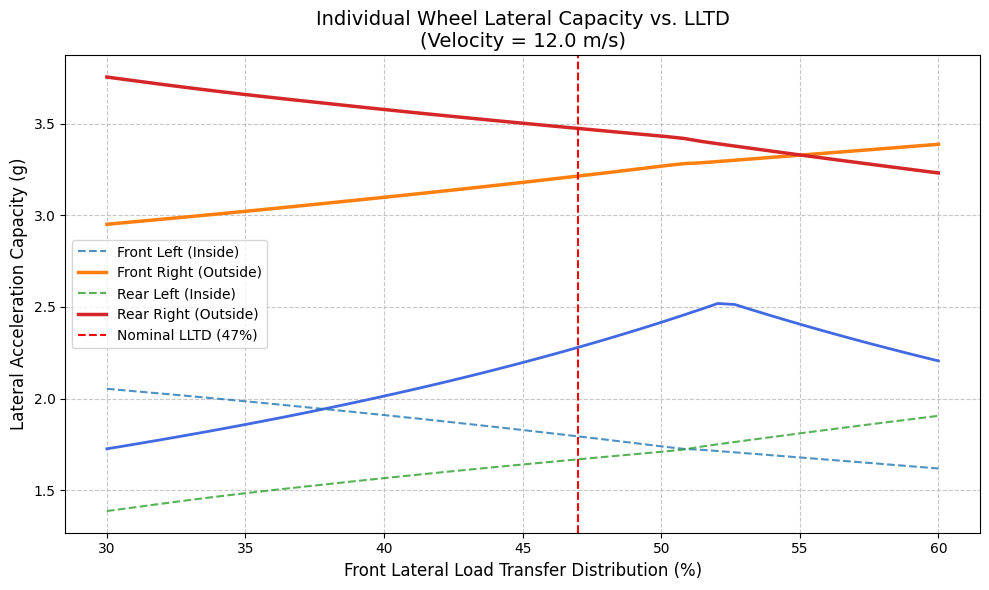

In [ ]:
# Aero
RHO = 1.225
CL = -1.937755                 # Downforce coeff (negative, so we take abs)
A = 1.0                 # m^2
AERO_FRONT_BAL = 0.50   # Aero balance

# Simulation Constraints
MAX_VELOCITY = 12.0         # m/s 
ITERATIONS = 10

# Sweep LLTD from 0.3 to 0.6
lltd_values = np.linspace(0.3, 0.6, 50)
max_ay_results = []
ay_fl_results = []
ay_fr_results = []
ay_rl_results = []
ay_rr_results = []

def per_wheel_lat_limits(V, k_longitudinal=2, phi_front=PHI_FRONT):
    ay_guess = 0.0
    
    for _ in range(PER_WHEEL_SPEED_ITERATIONS):
        # Get current vertical loads based on current ay guess
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(
            V, ax=0.0, ay=ay_guess, k_longitudinal=k_longitudinal, phi_front=phi_front
        )
        
        # Calculate max lateral force capacity for each tire (Fy = mu * Fz)
        fy_max_fl = peak_lateral(Fz_fl)
        fy_max_fr = peak_lateral(Fz_fr)
        fy_max_rl = peak_lateral(Fz_rl)
        fy_max_rr = peak_lateral(Fz_rr)
        
        # Convert force to acceleration capacity (a = F / m)
        ay_fl = fy_max_fl / (M * FRONT_STATIC_FRAC / 2.0)
        ay_fr = fy_max_fr / (M * FRONT_STATIC_FRAC / 2.0)
        ay_rl = fy_max_rl / (M * (1.0 - FRONT_STATIC_FRAC) / 2.0)
        ay_rr = fy_max_rr / (M * (1.0 - FRONT_STATIC_FRAC) / 2.0)

        ay_next = min(ay_fl, ay_fr, ay_rl, ay_rr)
        
        if abs(ay_next - ay_guess) < 1e-3:
            break
        ay_guess = ay_next

    return ay_fl, ay_fr, ay_rl, ay_rr

for phi in lltd_values:
    _, _, max_ay = per_speed_limits(MAX_VELOCITY, k_longitudinal=K_LONGITUDINAL, phi_front=phi)
    max_ay = max_ay 
    max_ay_results.append(max_ay)

    ay_fl, ay_fr, ay_rl, ay_rr = per_wheel_lat_limits(MAX_VELOCITY, k_longitudinal=K_LONGITUDINAL, phi_front=phi)
    
    ay_fl_results.append(ay_fl)
    ay_fr_results.append(ay_fr)
    ay_rl_results.append(ay_rl)
    ay_rr_results.append(ay_rr)

ay_fl_results = np.array(ay_fl_results) / G
ay_fr_results = np.array(ay_fr_results) / G
ay_rl_results = np.array(ay_rl_results) / G
ay_rr_results = np.array(ay_rr_results) / G


# PLOT EVERYTHNG WHOOP WHOOP
# Create the figure and axes objects
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data on the axes object
ax.plot(lltd_values * 100, np.array(max_ay_results) / G, linewidth=2, color='royalblue')
ax.plot(lltd_values * 100, ay_fl_results, label='Front Left (Inside)', linestyle='--', alpha=0.8)
ax.plot(lltd_values * 100, ay_fr_results, label='Front Right (Outside)', linewidth=2.5)
ax.plot(lltd_values * 100, ay_rl_results, label='Rear Left (Inside)', linestyle='--', alpha=0.8)
ax.plot(lltd_values * 100, ay_rr_results, label='Rear Right (Outside)', linewidth=2.5)

# Add the reference line
ax.axvline(x=47, color='red', linestyle='--', label='Nominal LLTD (47%)')

# Set titles and labels using the 'set_' prefix
ax.set_title(f'Max Lateral Acceleration vs. LLTD\n(Velocity = {MAX_VELOCITY} m/s)', fontsize=14)
ax.set_xlabel('Front Lateral Load Transfer Distribution (%)', fontsize=12)
ax.set_ylabel('Max Lateral Acceleration (g)', fontsize=12)
ax.set_title(f'Individual Wheel Lateral Capacity vs. LLTD\n(Velocity = {MAX_VELOCITY} m/s)', fontsize=14)
ax.set_xlabel('Front Lateral Load Transfer Distribution (%)', fontsize=12)
ax.set_ylabel('Lateral Acceleration Capacity (g)', fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True)

# Configure grid and legend
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend()

fig.tight_layout()
plt.show()